# Text preprocessing

In [1]:
import sys, os
print("Python exe:", sys.executable)
print("CWD:", os.getcwd())


Python exe: c:\Users\shire\OneDrive\Fac\DevelopersInstitute\GenAI\week7\day1\DailyChallenge\.venv\Scripts\python.exe
CWD: c:\Users\shire\OneDrive\Fac\DevelopersInstitute\GenAI\week7\day1\DailyChallenge\notebook


In [14]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])


0

In [2]:
import sys, os, platform
print("Python exe:", sys.executable)
print("Kernel OK, venv:", ".venv" in sys.executable)
print("CWD:", os.getcwd())
print("Python:", platform.python_version())


Python exe: c:\Users\shire\OneDrive\Fac\DevelopersInstitute\GenAI\week7\day1\DailyChallenge\.venv\Scripts\python.exe
Kernel OK, venv: True
CWD: c:\Users\shire\OneDrive\Fac\DevelopersInstitute\GenAI\week7\day1\DailyChallenge\notebook
Python: 3.11.2


In [3]:
%pip install -U pip
%pip install requests regex nltk spacy scikit-learn wordcloud matplotlib


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### 1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.

In [4]:
import requests, re

def load_texts(urls):
    corpus = []
    for url in urls:
        # 1. download the text
        r = requests.get(url)
        text = r.text

        # 2. Take of Gutenberg's header and footer
        start = text.find("*** START")
        end   = text.find("*** END")
        if start != -1 and end != -1:
            text = text[start:end]

        # 3. Cleaning : keep letters, spaces, apostrophes
        text = re.sub(r"[^A-Za-z'\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

        # 4. Stock
        corpus.append(text)
    return corpus


### 2. Print the first 200 characteres of each text.

Are there parts of the text that are not relevant to the analysis? If so, you need to remove them.

hint: You can use slicing to start and stop the text where you need (ignoring autoral credits in the begining and end) looking for the following phrases:

‘ START’
‘ END’

In [6]:
URLS = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
]

corpus = load_texts(URLS)
for i, txt in enumerate(corpus):
    print(f"\nBook {i} → extract :\n", txt[:200])



Book 0 → extract :
 START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION Contents CHAPTER I Down the Rabbit H

Book 1 → extract :
 START OF THE PROJECT GUTENBERG EBOOK THROUGH THE LOOKING GLASS Illustration THROUGH THE LOOKING GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition DRAMATIS PERSON As arra

Book 2 → extract :
 START OF THE PROJECT GUTENBERG EBOOK A TANGLED TALE Produced by Chris Curnow Carla Foust Lindy Walsh and the Online Distributed Proofreading Team at https www pgdp net Music transcribed by Linda Canto


### 3. Tokenize the text and print the first 150 tokens of each book

In [8]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

tokens = [word_tokenize(text.lower()) for text in corpus]
for i, txt in enumerate(corpus):
    print(f"\nBook {i} → tokens :\n", tokens[i][:150])  # first 150 tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Book 0 → tokens :
 ['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', "'s", 'adventures', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'tea', 'party', 'chapter', 'viii', 'the', 'queen', 's', 'croquet', 'ground', 'chapter', 'ix', 'the', 'mock', 'turtle', 's', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alice', 's', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'alice', 'was', 'beginning', 'to', 'get', 'ver

### 4. Remove stopwords using NLTK. Check that they were removed using count() and looking for some of the stop words like: ‘i’, ‘me’, ‘my’, ‘myself’, ‘we’, ‘our’, ‘ours’, ‘ourselves’, etc.

In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords # import the stopwords module

stop_words = set(stopwords.words('english'))  # get the English stopwords

filtered_tokens = []
for i, book_tokens in enumerate(tokens):
    filtered = [word for word in book_tokens if word.isalpha() and word not in stop_words]
    filtered_tokens.append(filtered)
    print(f"\nBook {i} → filtered tokens :\n", filtered_tokens[:150])  # first 150 filtered tokens


Book 0 → filtered tokens :
 [['start', 'project', 'gutenberg', 'ebook', 'alice', 'adventures', 'wonderland', 'illustration', 'alice', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'sends', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter', 'viii', 'queen', 'croquet', 'ground', 'chapter', 'ix', 'mock', 'turtle', 'story', 'chapter', 'x', 'lobster', 'quadrille', 'chapter', 'xi', 'stole', 'tarts', 'chapter', 'xii', 'alice', 'evidence', 'chapter', 'rabbit', 'hole', 'alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'nothing', 'twice', 'peeped', 'book', 'sister', 'reading', 'pictures', 'conversations', 'use', 'book', 'thought', 'alice', 'without', 'pictures', 'conversations', 'considering', 'mi

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
probe = ['i','me','my','myself','we','our','ours','ourselves']
for i, filtered in enumerate(filtered_tokens):
    counts = {w: filtered.count(w) for w in probe}
    print(f"\nBook {i} stopword counts:", counts)



Book 0 stopword counts: {'i': 0, 'me': 0, 'my': 0, 'myself': 0, 'we': 0, 'our': 0, 'ours': 0, 'ourselves': 0}

Book 1 stopword counts: {'i': 0, 'me': 0, 'my': 0, 'myself': 0, 'we': 0, 'our': 0, 'ours': 0, 'ourselves': 0}

Book 2 stopword counts: {'i': 0, 'me': 0, 'my': 0, 'myself': 0, 'we': 0, 'our': 0, 'ours': 0, 'ourselves': 0}


### 5. Using PorterStemmer(), print the first 50 stemmed tokens

In [12]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_books = []
for i, book_tokens in enumerate(filtered_tokens):
    stems = [stemmer.stem(word) for word in book_tokens]
    stemmed_books.append(stems)
    print(f"\nBook {i} → first 50 stems:\n", stems[:50])


Book 0 → first 50 stems:
 ['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter']

Book 1 → first 50 stems:
 ['start', 'project', 'gutenberg', 'ebook', 'look', 'glass', 'illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 'fawn']

Book 2 → f

### 6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens. Hint: in spaCy the lemmatized token can be accessed as attribute.

In [15]:
import spacy

#load spaCy's English language model
nlp = spacy.load('en_core_web_sm')

lemmatized_books = []
for i, book_tokens in enumerate(filtered_tokens):
    text = ' '.join(book_tokens[:2000])  # join first 2000 tokens into a string
    doc = nlp(text)
    lemmas = [token.lemma_.lower() for token in doc if token.lemma_.isalpha()]
    lemmatized_books.append(lemmas)
    print(f"\nBook {i} → first 50 lemmas:\n", lemmas[:50])



Book 0 → first 50 lemmas:
 ['start', 'project', 'gutenberg', 'ebook', 'alice', 'adventures', 'wonderland', 'illustration', 'alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter']

Book 1 → first 50 lemmas:
 ['start', 'project', 'gutenberg', 'ebook', 'look', 'glass', 'illustration', 'look', 'glass', 'alice', 'find', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'arrange', 'commencement', 'game', 'white', 'red', 'piece', 'pawn', 'pawn', 'piece', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus', 'w', 'queen', 'lily', 'tiger', 'lily', 

### 7. Analyse the difference between the stemmed and lemmatized tokens. What is different and why?


- **Stemming**: a crude heuristic process that chops off word endings to get to the "root".  
  It does not care about grammar or context.  
  Example: *studies → studi*, *better → better*.  
  The result is often not a valid dictionary word.

- **Lemmatization**: a more intelligent process that uses vocabulary and morphological analysis.  
  It reduces words to their base **lemma** form, considering context and part of speech.  
  Example: *studies → study*, *better → good*.  
  The result is always a valid word.

In short: stemming is faster but less accurate, lemmatization is slower but gives cleaner, more meaningful tokens.


### 8. Using NLTK, identify POS tags od each text.

In [16]:
import nltk
from nltk import pos_tag

# Download the 'averaged_perceptron_tagger_eng' resource
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

tagged_books = []
for i, book_tokens in enumerate(filtered_tokens):
    tagged = pos_tag(book_tokens[:200])
    tagged_books.append(tagged)
    print(f"\nBook {i} → first 50 POS tags:\n", tagged[:50])

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!



Book 0 → first 50 POS tags:
 [('start', 'NN'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('alice', 'NN'), ('adventures', 'NNS'), ('wonderland', 'VBP'), ('illustration', 'NN'), ('alice', 'NN'), ('adventures', 'NNS'), ('wonderland', 'VBP'), ('lewis', 'JJ'), ('carroll', 'NN'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('rabbit', 'NN'), ('hole', 'JJ'), ('chapter', 'NN'), ('ii', 'NN'), ('pool', 'NN'), ('tears', 'NNS'), ('chapter', 'NN'), ('iii', 'VBP'), ('caucus', 'NN'), ('race', 'NN'), ('long', 'JJ'), ('tale', 'JJ'), ('chapter', 'NN'), ('iv', 'NN'), ('rabbit', 'NN'), ('sends', 'VBZ'), ('little', 'JJ'), ('bill', 'NN'), ('chapter', 'NN'), ('v', 'NN'), ('advice', 'NN'), ('caterpillar', 'JJ'), ('chapter', 'NN'), ('vi', 'NN'), ('pig', 'NN'), ('pepper', 'IN'), ('chapter', 'NN'), ('vii', 'NN'), ('mad', 'JJ'), ('tea', 'NN'), ('party', 'NN'), ('chapter', 'NN')]

Book 1 → first 50 POS tags:
 [('start', 'NN'), ('project', 'NN')

### 9. Using NLTK identify all the entities of each text



In [18]:
import nltk
from nltk import pos_tag, ne_chunk, word_tokenize

# download 
nltk.download("averaged_perceptron_tagger")
nltk.download("maxent_ne_chunker")
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")
nltk.download("punkt")

# for each book
for i, text in enumerate(corpus):   # corpus = list of strings (cleaned)
    tokens = word_tokenize(text[:2000]) 
    tagged = pos_tag(tokens)
    tree = ne_chunk(tagged)

    print(f"\nBook {i} → sample entities:\n")
    print(tree)   


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping chunkers\maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shire\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Book 0 → sample entities:

(S
  START/NNP
  OF/IN
  (ORGANIZATION THE/NNP)
  (ORGANIZATION PROJECT/NNP)
  GUTENBERG/NNP
  EBOOK/NNP
  ALICE/NNP
  'S/POS
  (ORGANIZATION ADVENTURES/NNP)
  IN/NNP
  WONDERLAND/NNP
  Illustration/NNP
  Alice/NNP
  s/NN
  Adventures/NNP
  in/IN
  (GPE Wonderland/NNP)
  by/IN
  (PERSON Lewis/NNP Carroll/NNP THE/NNP)
  (ORGANIZATION MILLENNIUM/NNP)
  FULCRUM/NNP
  EDITION/NNP
  Contents/NNP
  CHAPTER/NN
  I/PRP
  Down/RP
  the/DT
  (ORGANIZATION Rabbit/NNP Hole/NNP)
  CHAPTER/NNP
  II/NNP
  The/DT
  (ORGANIZATION Pool/NNP)
  of/IN
  (PERSON Tears/NNP)
  CHAPTER/NNP
  III/NNP
  A/NNP
  Caucus/NNP
  Race/NNP
  and/CC
  a/DT
  (ORGANIZATION Long/JJ Tale/NNP)
  CHAPTER/NNP
  IV/NNP
  The/DT
  (ORGANIZATION Rabbit/NNP Sends/NNPS)
  in/IN
  a/DT
  Little/JJ
  (PERSON Bill/NNP)
  CHAPTER/NNP
  V/NNP
  Advice/NNP
  from/IN
  a/DT
  (ORGANIZATION Caterpillar/NNP)
  CHAPTER/NNP
  VI/NNP
  Pig/NNP
  and/CC
  (PERSON Pepper/NNP)
  CHAPTER/NNP
  VII/NNP
  A/NNP
  Mad/NNP

# Analysing the text

### 1. Using wordcloud and matplotlib, display a word cloud of each book.

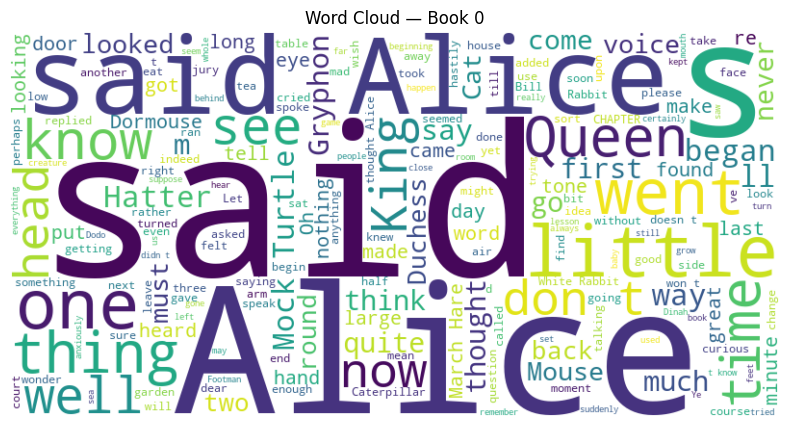

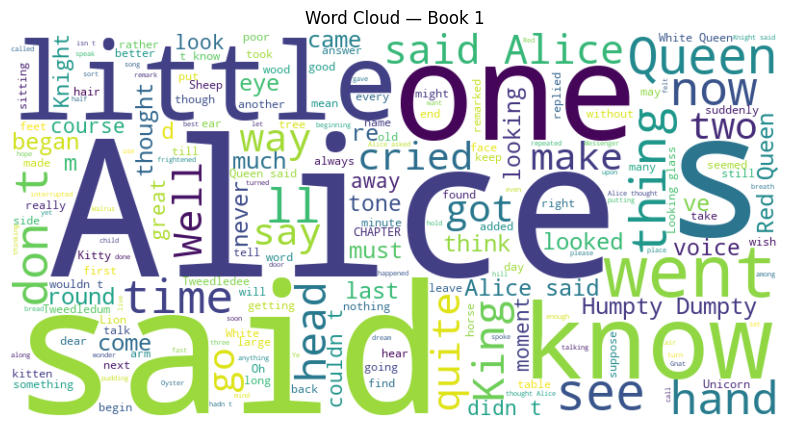

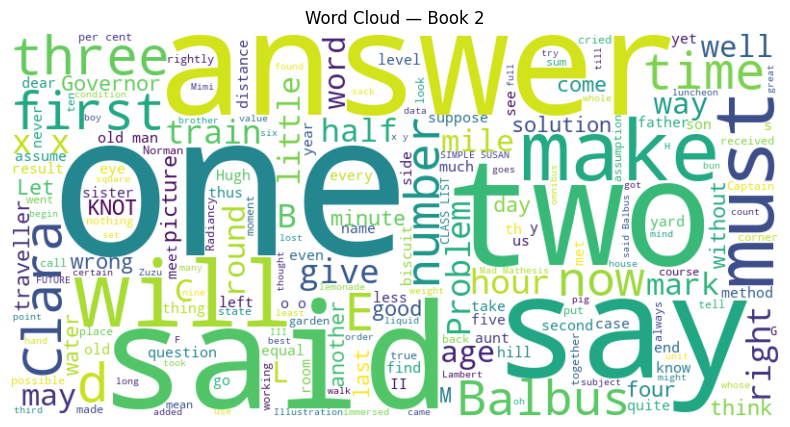

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for i, text in enumerate(corpus):  # corpus = list of strings (cleaned text)
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — Book {i}")
    plt.show()


### 2. Use BoW method to check the five most frequent words in all the books

hint: What will be the best text from the preprocess step? (raw text, stemmed, lemmarized, etc)?

The best choice is to use **lemmatized tokens**.  
- Raw text still contains punctuation, stopwords and different word forms.  
- Stemmed tokens are crude and may cut words into non-dictionary forms
- Lemmatization normalizes words to their dictionary base form, which makes the Bag of Words more meaningful and easier to interpret.


In [20]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# 1. Join lemmas back into strings (one per book)
texts_lemmas = [" ".join(book) for book in lemmatized_books]

# 2. Create Bag of Words
cv = CountVectorizer()
X = cv.fit_transform(texts_lemmas)

# 3. Compute global frequency
total_counts = np.asarray(X.sum(axis=0)).ravel()
terms = np.array(cv.get_feature_names_out())

# 4. Get top 5
idx_top5 = total_counts.argsort()[::-1][:5]
print("Top 5 words (GLOBAL across all books):")
for idx in idx_top5:
    print(terms[idx], total_counts[idx])


Top 5 words (GLOBAL across all books):
say 114
alice 103
go 68
one 64
see 57


### 3. Print the BoW and identify the numbers: What is the document number? What is the index and what is how many times the word was found?

In [21]:
# Show BoW shape
print("BoW shape:", X.shape)  
# (n_docs, n_terms) = (3 books, nb de mots differents)

# Vocabulary (word -> column index)
vocab = cv.vocabulary_  # dict: mot -> index colonne
print("\nSample of vocabulary (word -> column index):")
for word, idx in list(vocab.items())[:10]:
    print(word, "->", idx)

# Inspect BoW values
X_array = X.toarray()   # convert sparse matrix to normal array
print("\nBoW matrix (first 5 words in vocab):")
print(X_array[:, :5])


BoW shape: (3, 1789)

Sample of vocabulary (word -> column index):
start -> 1483
project -> 1206
gutenberg -> 681
ebook -> 456
alice -> 36
adventures -> 17
wonderland -> 1758
illustration -> 765
adventure -> 16
lewis -> 882

BoW matrix (first 5 words in vocab):
[[1 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 1 1]]


### 4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels.

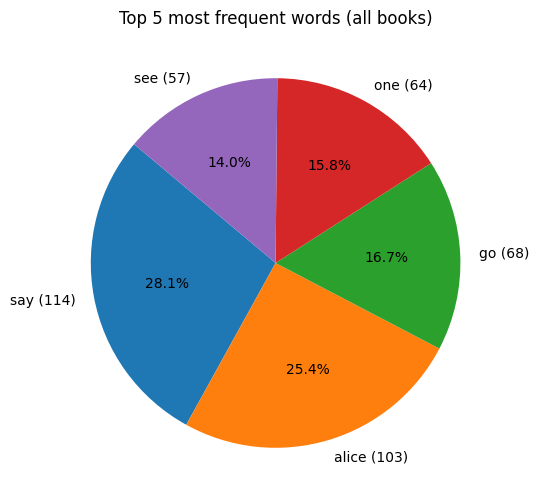

In [22]:
import matplotlib.pyplot as plt

# On réutilise les totaux globaux (déjà calculés en Q2)
total_counts = np.asarray(X.sum(axis=0)).ravel()
terms = np.array(cv.get_feature_names_out())

# Top 5
idx_top5 = total_counts.argsort()[::-1][:5]
labels = [f"{terms[idx]} ({total_counts[idx]})" for idx in idx_top5]
sizes = [total_counts[idx] for idx in idx_top5]

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Top 5 most frequent words (all books)")
plt.show()


### 5. Analyse the outputs: Are those words informative? Are they insightful or expected?



The most frequent words are **not very informative**.  
They are usually common words from the story (like "Alice", "said", "little"), which are expected to appear often but do not give deep insights about the themes.  
They confirm the context but are less useful for analysis — that’s why TF-IDF is needed to highlight more meaningful terms.

# Solving the frequency problem using TF-IDF

### 1. Create another BoW, now using TF-IDF as vectorizer.

hint: You need to pass min_df=1, max_df=2 as arguments of the TfidfVectorizer(), because we are using a small dataset.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Join lemmas into strings (same as before)
texts_lemmas = [" ".join(book) for book in lemmatized_books]

# 2. Create TF-IDF vectorizer
tfidf = TfidfVectorizer(min_df=1, max_df=2)  # min_df=1, max_df=2 for small dataset
T = tfidf.fit_transform(texts_lemmas)

# 3. Show shape (documents × terms)
print("TF-IDF shape:", T.shape)

# 4. Vocabulary
terms = np.array(tfidf.get_feature_names_out())

# 5. Example: top 5 terms in the first book
row = T[0].toarray().ravel()
idx_top5 = row.argsort()[::-1][:5]
print("Top 5 terms in Book 0 (by TF-IDF):")
for idx in idx_top5:
    print(terms[idx], row[idx])


TF-IDF shape: (3, 1605)
Top 5 terms in Book 0 (by TF-IDF):
alice 0.598400823222734
mouse 0.3036869080554517
think 0.25195824135694067
rabbit 0.2070592554923534
oh 0.17847042096116628


### 2. Create again the pie plots with the new 5 most relevant words from each document.


Top 5 TF-IDF terms — Book 0:
alice (0.598)
mouse (0.304)
think (0.252)
rabbit (0.207)
oh (0.178)


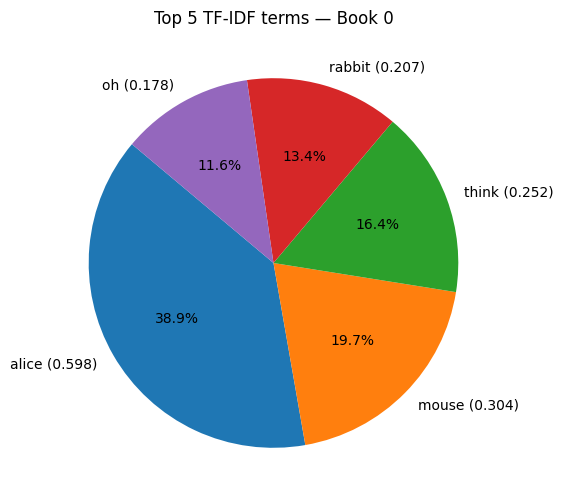


Top 5 TF-IDF terms — Book 1:
alice (0.517)
king (0.281)
kitty (0.266)
kitten (0.251)
queen (0.225)


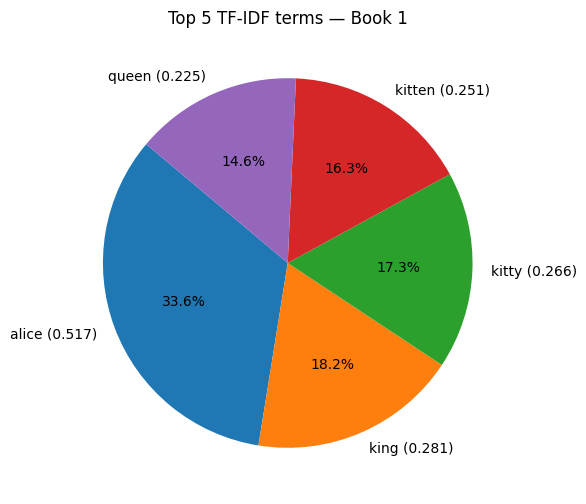


Top 5 TF-IDF terms — Book 2:
balbus (0.394)
train (0.268)
clara (0.221)
room (0.192)
mathesis (0.142)


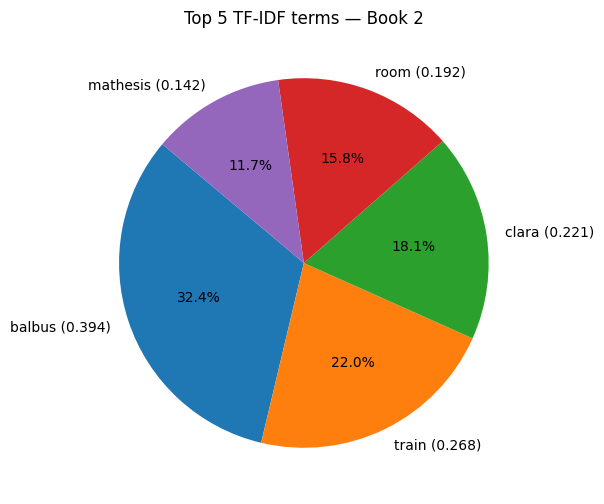

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Join lemmas into strings (if not already done)
texts_lemmas = [" ".join(book) for book in lemmatized_books]

# 2. TF-IDF vectorizer
tfidf = TfidfVectorizer(min_df=1, max_df=2)
T = tfidf.fit_transform(texts_lemmas)
terms = np.array(tfidf.get_feature_names_out())

# 3. Pie chart for each document
for i in range(T.shape[0]):
    row = T[i].toarray().ravel()
    idx_top5 = row.argsort()[::-1][:5]  # top 5 indices
    labels = [f"{terms[j]} ({row[j]:.3f})" for j in idx_top5]
    sizes = [row[j] for j in idx_top5]

    print(f"\nTop 5 TF-IDF terms — Book {i}:")
    for lab in labels:
        print(lab)

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140)
    plt.title(f"Top 5 TF-IDF terms — Book {i}")
    plt.show()
